### Legacy vs New Domain creation sanity checks

Author: <b> Sam MacKay </b> </br>

Check confirms (as I already though this was just a sanity check after changes as this was confirmed in tests after the original updates) that domain generation is the same between version.

What is the reason for the disparity in the small box tests then?
Is there a difference in default options or overrides?

Fix this before further investigating of small scale changes, so I can eliminate a potential cause of interference to disparity tests

<b> Fixed: </b> Manually set values for domain to override defaults
smaller beam test had different refraction due to vastly different domain (shrinking it of course doesnt just make it the same thing but smaller, as its variance is dependent on its size) - it essentially reduces it from a cos function to one wavelength range of that function (therefore no periodicity or associated results)

To test my theory I have set the small beam and small domain, but with the spatial sinusoidal perturbation scaled such that it should match the beam/domain scaling (etc. s *= 10, = default_value * (1/new) * (1/old)). This should produce the same domain as for regular usage but with different axis values (as the pattern is now the same but repeating over a smaller range) if my assumptions are correct. It does (ray images produced won't be the same due to discrepancy in divergence scaling, behaviour at edges as there is in fact a periodic domain it can extend into unlike the fully reduced example, effects of different size despite not changing wavelength ... etc.).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

#add path
sys.path.insert(0, '../../')     # import path/to/synthpy

import src.simulator.config as config
config.jax_init(force_device = "cpu")

import simulator.beam as beam_initialiser
import simulator.domain as d
import simulator.propagator as p
import processing.diagnostics as diag

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: /home/administrator/Programs/synthPy/src

Disabling python multi-threading...
Initialising jax...

Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15)]


<module 'processing.diagnostics' from '/home/administrator/Programs/synthPy/src/processing/diagnostics.py'>

In [2]:
import os

#top_level_path = resolve_path(str(os.path.dirname(os.path.realpath(__file__))) + "/../")
top_level_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
print("Setting top level path for imports:", top_level_path)

# Ensure top-level path is in sys.path
if top_level_path not in sys.path:
    # makes sure top level directory path is present in system so that relative imports work
    sys.path.insert(0, top_level_path)

import legacy.full_solver as fs

importlib.reload(fs)

Setting top level path for imports: /home/administrator/Programs/synthPy/src


<module 'legacy.full_solver' from '/home/administrator/Programs/synthPy/src/legacy/full_solver.py'>

In [3]:
extent_x = 5e-3
extent_y = 5e-3

extent_x_2 = 5e-4
extent_y_2 = 5e-4

extent_z = 10e-3

n_cells = 128

probing_extent = extent_z
probing_direction = 'z'

In [4]:
import jax.numpy as jnp

x = jnp.float32(jnp.linspace(-extent_x / 2, extent_x / 2, n_cells))
y = jnp.float32(jnp.linspace(-extent_y / 2, extent_y / 2, n_cells))
z = jnp.float32(jnp.linspace(-extent_z / 2, extent_z / 2, n_cells))

XX, YY, _ = jnp.meshgrid(x, y, z, indexing = 'ij', copy = True)

ne_0 = 1e24
Ly = 1e-3
s = -2e-3

ne_legacy = 10**(XX/s)*(1+np.cos(2*np.pi*YY/Ly))#*ne_0
ne_legacy_jaxed = 10**(XX/s)*(1+jnp.cos(2*jnp.pi*YY/Ly))#*ne_0

XX = XX.at[:, :, :].set(XX / s)
XX = XX.at[:, :, :].set(10 ** XX)

YY = YY.at[:, :, :].set(YY / Ly)
YY = YY.at[:, :, :].set(jnp.pi * YY)
YY = YY.at[:, :, :].set(2 * YY)
YY = YY.at[:, :, :].set(jnp.cos(YY))
YY = YY.at[:, :, :].set(1 + YY)

ne_new = XX * YY
#ne_new = ne_new.at[:, :, :].set(ne_0 * ne_new)

print("\nLEGACY:\n")
print(ne_legacy)
print("\nLEGACY JAXED:\n")
print(ne_legacy_jaxed)
print("\nNEW:\n")
print(ne_new)


LEGACY:

[[[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [5.4130870e-01 5.4130870e-01 5.4130870e-01 ... 5.4130870e-01
   5.4130870e-01 5.4130870e-01]
  [2.1322856e+00 2.1322856e+00 2.1322856e+00 ... 2.1322856e+00
   2.1322856e+00 2.1322856e+00]
  ...
  [2.1322856e+00 2.1322856e+00 2.1322856e+00 ... 2.1322856e+00
   2.1322856e+00 2.1322856e+00]
  [5.4130870e-01 5.4130870e-01 5.4130870e-01 ... 5.4130870e-01
   5.4130870e-01 5.4130870e-01]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]]

 [[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
   0.0000000e+00 0.0000000e+00]
  [5.1732081e-01 5.1732081e-01 5.1732081e-01 ... 5.1732081e-01
   5.1732081e-01 5.1732081e-01]
  [2.0377944e+00 2.0377944e+00 2.0377944e+00 ... 2.0377944e+00
   2.0377944e+00 2.0377944e+00]
  ...
  [2.0377944e+00 2.0377944e+00 2.0377944e+00 ... 2.0377944e+00
   2.0377944e+00 2.0377944e+00]
  [5.1732081e-01 5.1732081

In [5]:
lengths = 2 * np.array([extent_x, extent_y, extent_z])
lengths_2 = 2 * np.array([extent_x_2, extent_y_2, extent_z])

domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, ne_0 = ne_0, Ly = Ly, s = s)
domain_2 = d.ScalarDomain(lengths_2, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, ne_0 = ne_0, Ly = Ly, s = s)

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982200622558594 GB
 - free  : 1.7746200561523438 GB
 - used  : 13.24100112915039 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...
Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982200622558594 GB
 - free  : 1.7415275573730469 GB
 - used  : 13.27396011352539 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


In [6]:
ne_x = np.linspace(-extent_x,extent_x, n_cells)
ne_y = np.linspace(-extent_y,extent_y, n_cells)
ne_z = np.linspace(-extent_z,extent_z, n_cells)

ne_x_2 = np.linspace(-extent_x_2,extent_x_2, n_cells)
ne_y_2 = np.linspace(-extent_y_2,extent_y_2, n_cells)

slab = fs.ScalarDomain(ne_x, ne_y, ne_z, probing_extent)
slab.test_exponential_cos(n_e0 = ne_0, Ly = Ly, s = s)

slab_2 = fs.ScalarDomain(ne_x_2, ne_y_2, ne_z, probing_extent)
slab_2.test_exponential_cos(n_e0 = ne_0, Ly = Ly, s = s)

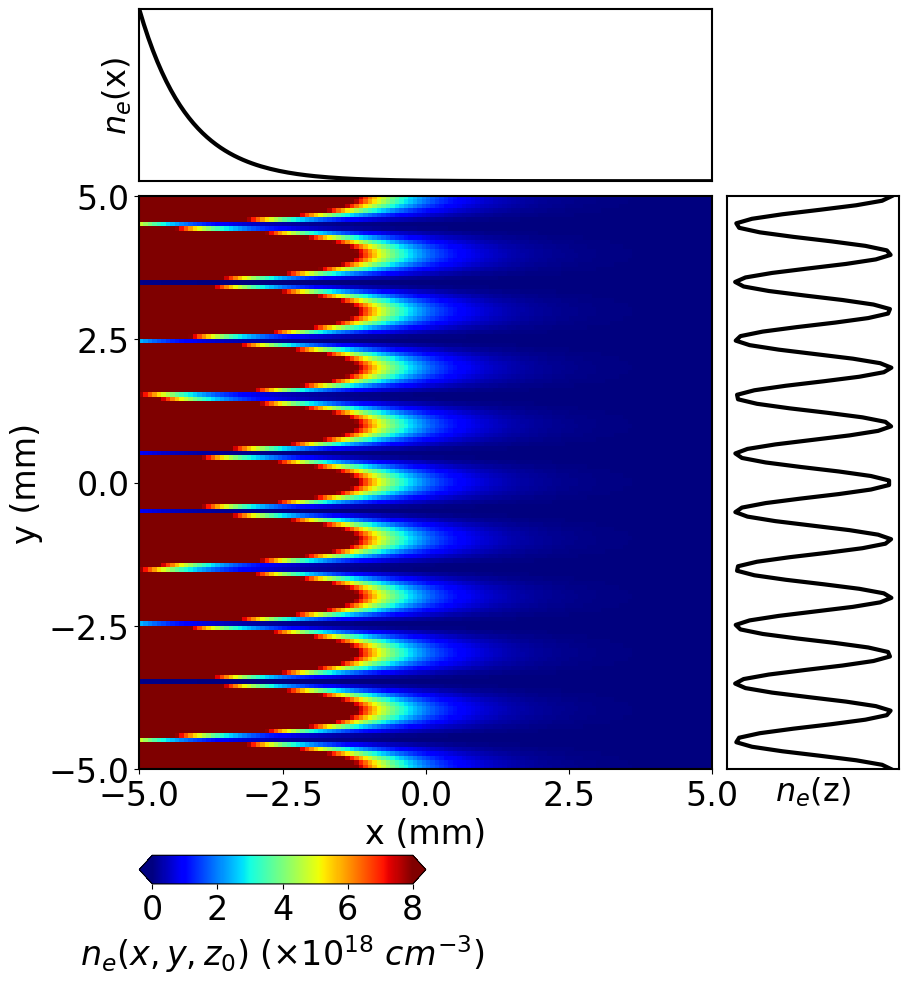

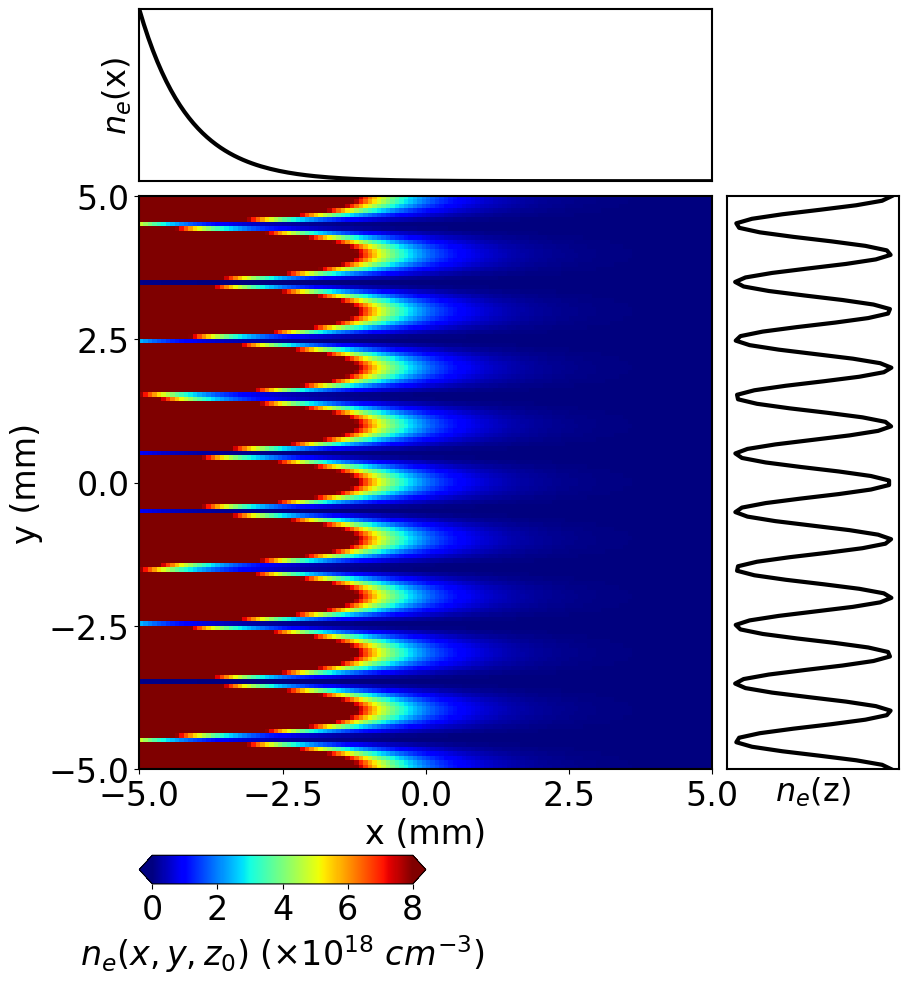

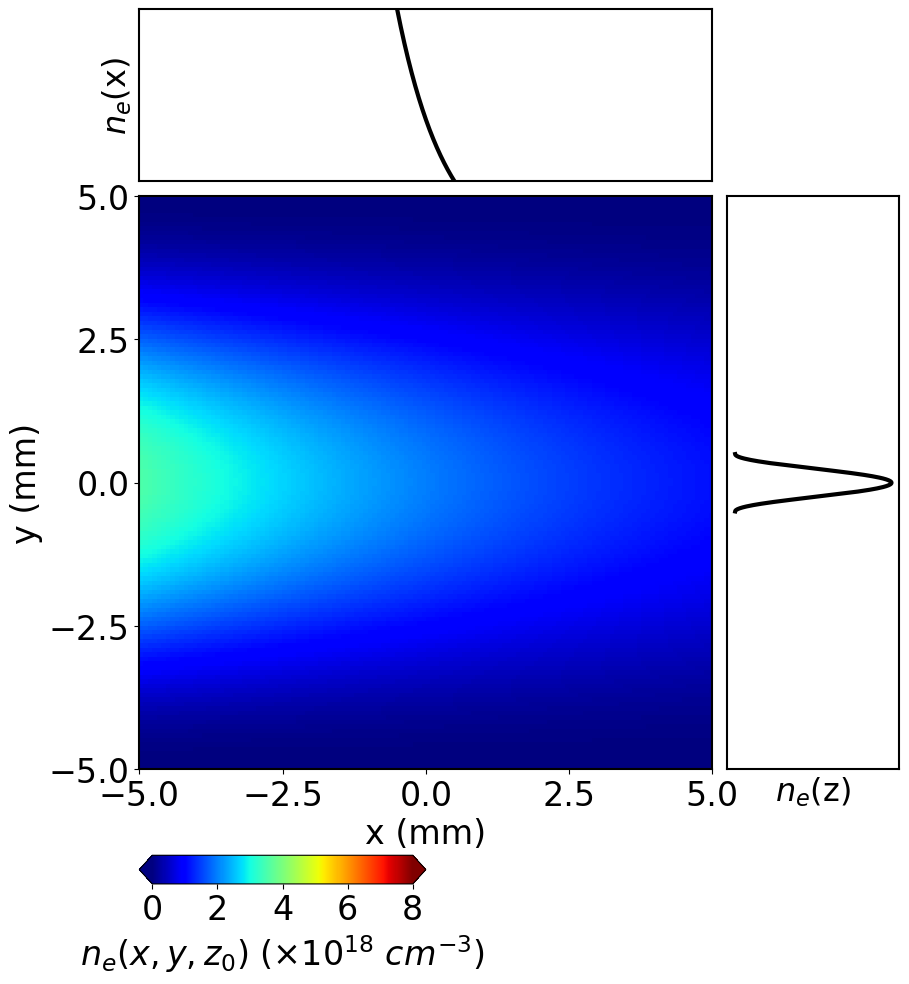

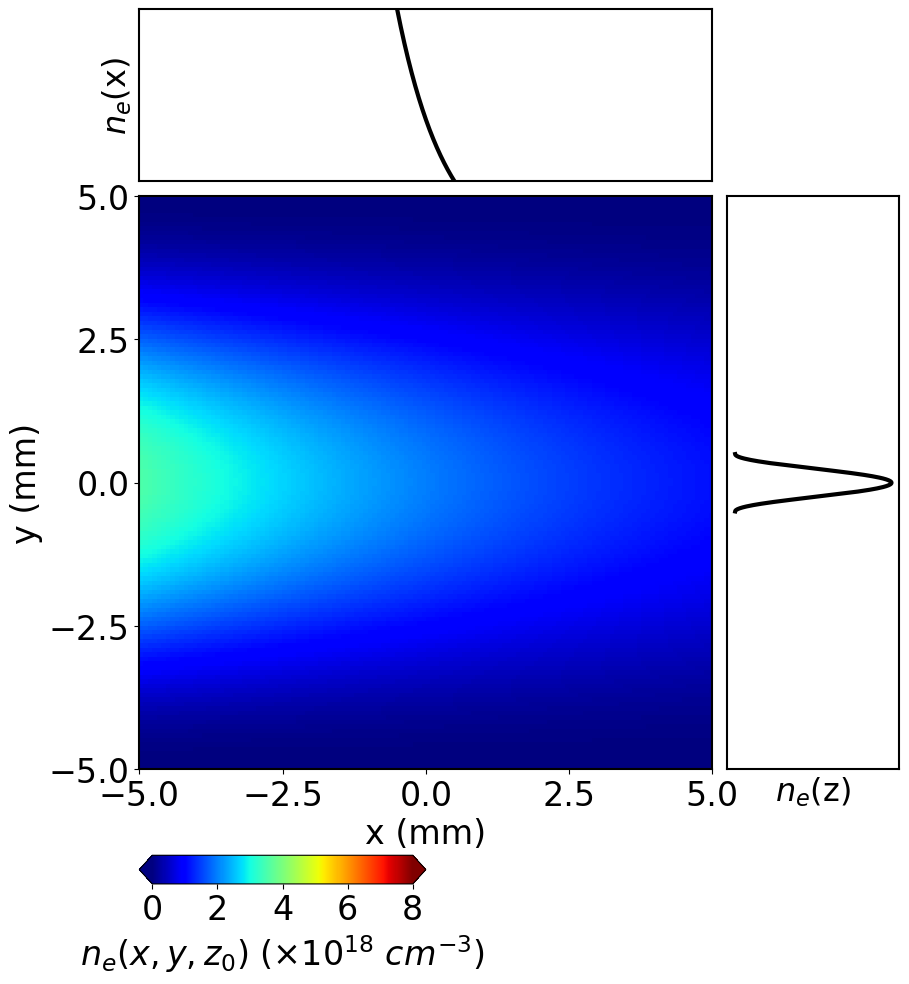

In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from processing.plotting import graph_domain

graph_domain(domain)
graph_domain(slab)

graph_domain(domain_2)
graph_domain(slab_2)

Text(0, 0.5, 'e- density')

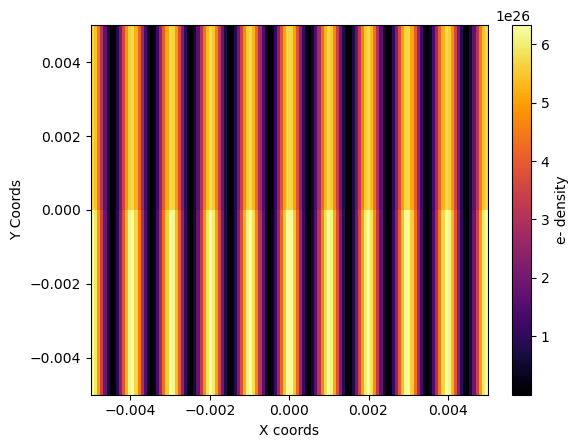

In [8]:
xy = domain.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [domain.x[0], domain.x[-1], domain.y[0], domain.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')

Text(0, 0.5, 'e- density')

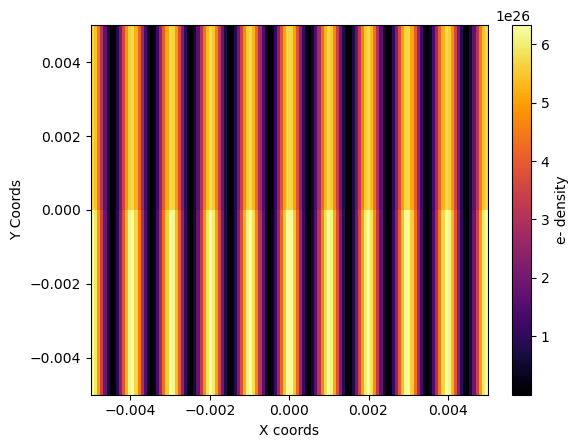

In [9]:
xy = slab.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [slab.x[0], slab.x[-1], slab.y[0], slab.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')

Text(0, 0.5, 'e- density')

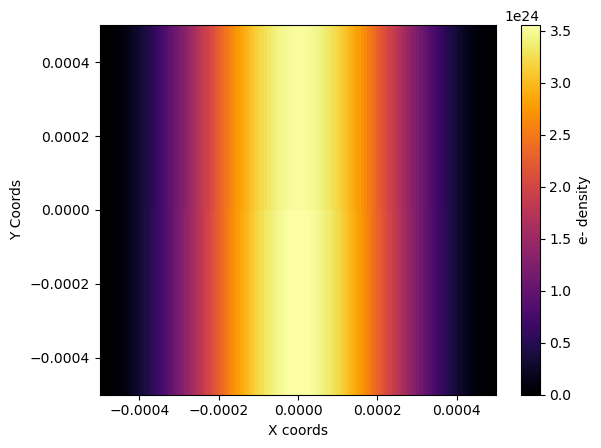

In [10]:
xy = domain_2.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [domain_2.x[0], domain_2.x[-1], domain_2.y[0], domain_2.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')

Text(0, 0.5, 'e- density')

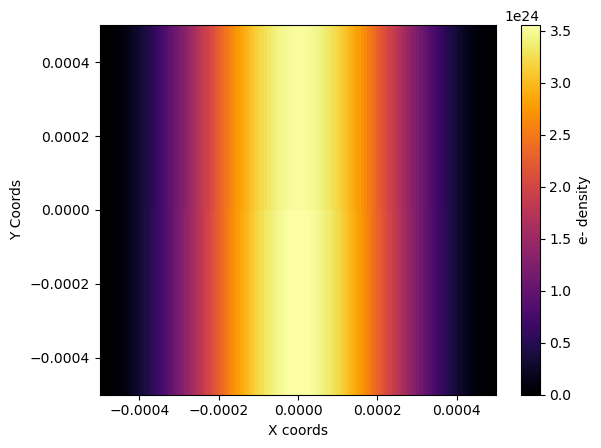

In [11]:
xy = slab_2.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [slab_2.x[0], slab_2.x[-1], slab_2.y[0], slab_2.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 14.982200622558594 GB
 - free  : 1.6793212890625 GB
 - used  : 13.167301177978516 GB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


Text(0, 0.5, 'e- density')

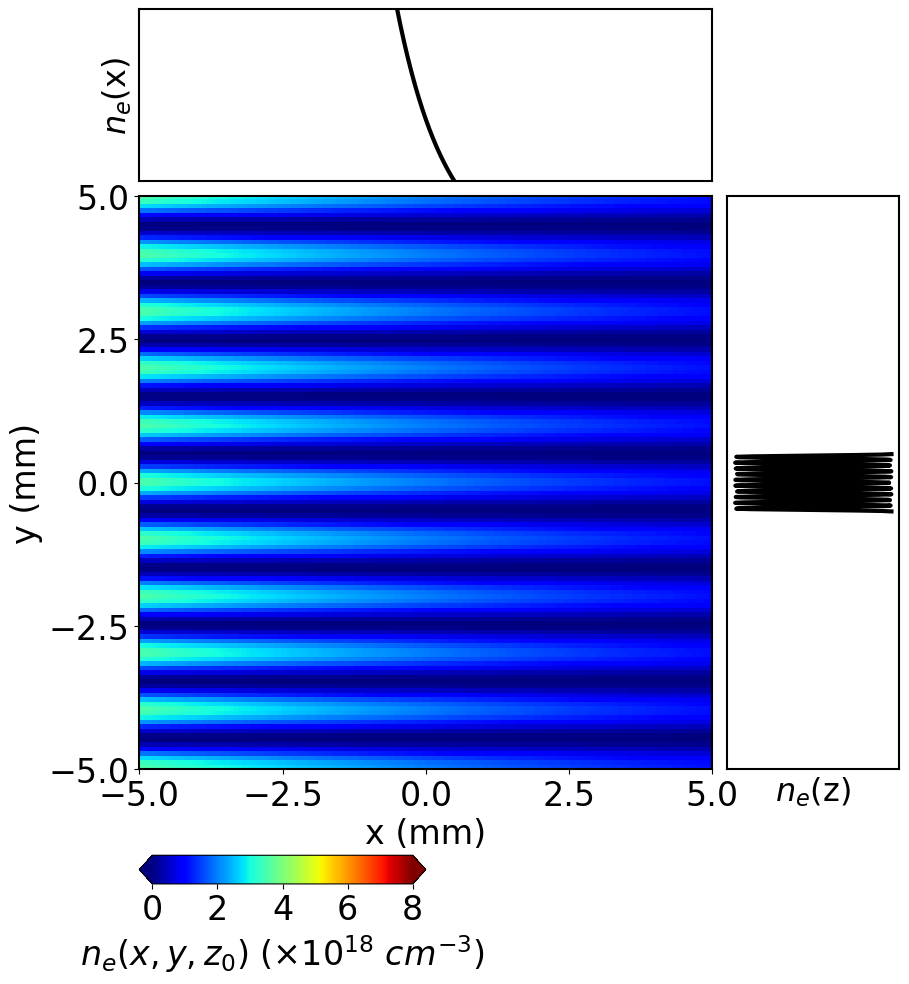

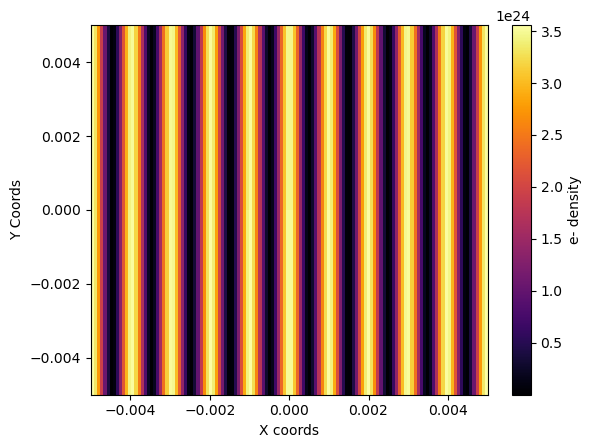

In [16]:
domain_2_scaled = d.ScalarDomain(lengths_2, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, ne_0 = 1e24, Ly = 1e-4, s = -2e-3)

graph_domain(domain_2_scaled)

xy = domain_2_scaled.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [domain.x[0], domain.x[-1], domain.y[0], domain.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 712 B): 135.80322265625 MB
 --> Np = 200000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 16 cores.
NamedSharding(mesh=Mesh('rows': 16, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.004074811935424805 seconds
Completed ray trace in 22.121 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (200000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and tran

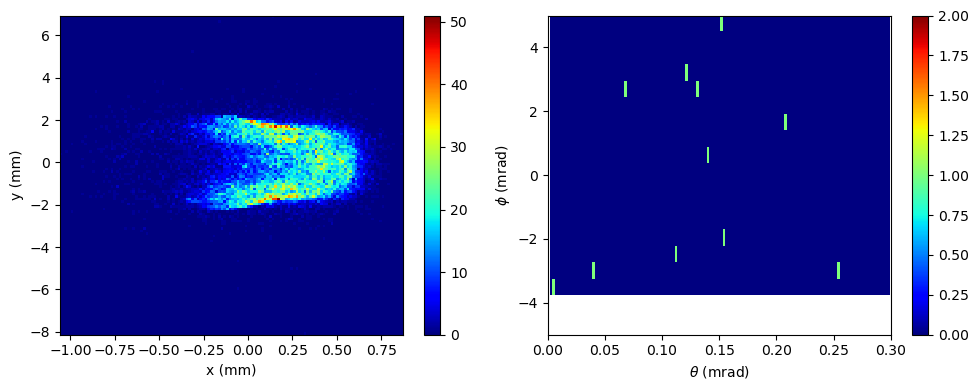

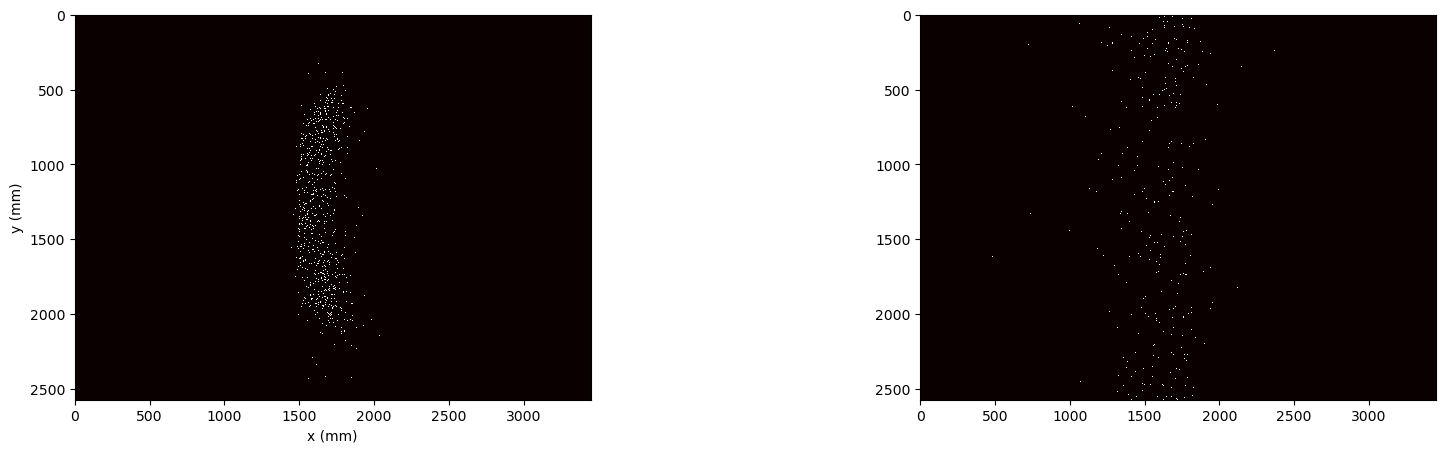

In [18]:
lwl = 1064e-9

Np = 200000
divergence = 5e-5
ne_extent = probing_extent
beam_type = 'circular'

beam_definition = beam_initialiser.Beam(
    Np, extent_x_2, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = "circular"
)

rf, _, duration = p.solve(beam_definition.s0, domain_2_scaled, probing_extent)

from processing.plotting import general_ray_plots
general_ray_plots(rf = rf, nbins = n_cells, lwl = lwl)